COVID-19 Early Case Trend Analysis & Recovery Insights
Business Understanding

1.1 Company Overview

HealthGuard Analytics Pvt. Ltd. is a healthcare data analytics company that provides data-driven insights to government health departments, hospitals, and public health organizations. The company specializes in analyzing healthcare datasets to identify disease trends, evaluate patient outcomes, and support evidence-based decision-making during public health emergencies.

For this project, HealthGuard Analytics has partnered with a national public health authority to analyze patient-level COVID-19 case records collected during the early stages of the outbreak. The analysis aims to uncover infection patterns, demographic characteristics, recovery trends, and regional distributions to support strategic public health planning and improve outbreak response.

1.2 Business Problem

The public health authority requires analytical insights from confirmed COVID-19 patient records to better understand the early progression of the outbreak.

The primary business questions include:

Who is getting infected based on demographic characteristics?
How are infections spreading among the population?
What are the recovery patterns of infected patients?
Which regions are experiencing the highest number of cases?
Which factors may influence patient recovery duration?

Answering these questions will help policymakers improve screening strategies, optimize healthcare resource allocation, strengthen contact tracing, and enhance future outbreak preparedness.

1.3 Project Objectives

The objectives of this project are:

Perform Exploratory Data Analysis (EDA) to understand the structure and quality of the dataset.
Analyze demographic characteristics such as age, gender, country, and region.
Investigate infection sources, infection order, and exposure-related factors.
Calculate patient recovery duration using confirmation and release dates.
Study regional case distribution and patient outcomes.
Perform descriptive statistical analysis to summarize the dataset.
Explore relationships between recovery duration and selected patient characteristics.
Develop a Linear Regression model to predict recovery duration, if sufficient data is available.

1.4 Business Value

The insights generated from this analysis can support healthcare authorities in making informed decisions by:

Identifying high-risk demographic groups.
Understanding dominant transmission patterns.
Monitoring regional disease burden.
Improving patient management strategies.
Supporting evidence-based public health planning.

1.5 Scope of the Project

This project focuses on patient-level COVID-19 case records available in the provided dataset. The analysis includes data preprocessing, exploratory data analysis, statistical analysis, feature engineering, and predictive modeling. The scope is limited to the available variables within the dataset and does not incorporate external healthcare or geographic datasets.

1.6 Expected Deliverables

By the completion of this project, the following deliverables will be produced:

Cleaned and processed dataset.
Exploratory Data Analysis with visualizations.
Statistical summary of patient characteristics.
Recovery duration analysis.
Regional trend analysis.
Linear Regression model (if applicable).
Business insights and recommendations.
Comprehensive analytical report.


In [151]:
# ==========================================================
# SECTION 2: IMPORT LIBRARIES
# ==========================================================

In [152]:
# -----------------------------
# Data Manipulation Libraries
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# Data Visualization Libraries
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Machine Learning Libraries
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------
# Warning Handling
# -----------------------------
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# Display Settings
# -----------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# -----------------------------
# Visualization Settings
# -----------------------------
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


In [153]:
from pathlib import Path

folders = [
    "../images/demographics",
    "../images/infection_analysis",
    "../images/recovery_analysis",
    "../images/regional_analysis",
    "../images/statistical_analysis",
    "../images/hypothesis_testing",
    "../images/predictive_analysis",
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

In [154]:
# ==========================================================
# SECTION 3: LOAD DATASET
# ==========================================================

In [155]:

# Dataset Path
dataset_path = "../data/raw/patient.csv"

# Load Dataset
df = pd.read_csv(dataset_path)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

# Display Dataset Dimensions
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset Loaded Successfully
Number of Rows    : 4212
Number of Columns : 14


In [156]:
# Display First Five Records
df.head()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.00,China,filtered at airport,NaN,visit to Wuhan,1.00,NaN,45.00,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.00,Korea,filtered at airport,NaN,visit to Wuhan,1.00,NaN,75.00,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.00,Korea,capital area,NaN,visit to Wuhan,1.00,NaN,16.00,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.00,Korea,capital area,NaN,visit to Wuhan,1.00,NaN,95.00,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.00,Korea,capital area,NaN,visit to Wuhan,1.00,NaN,31.00,2020-01-30,NaN,NaN,isolated


In [157]:
# Display Last Five Records
df.tail()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
4207,4208,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4208,4209,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4209,4210,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4210,4211,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4211,4212,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated


In [158]:
# ==========================================================
# 4.1 DATASET DIMENSIONS
# ==========================================================

In [159]:
print("="*60)
print("DATASET DIMENSIONS")
print("="*60)

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

DATASET DIMENSIONS
Number of Rows    : 4212
Number of Columns : 14


In [160]:
# ==========================================================
# 4.2 DATASET INFORMATION
# ==========================================================

In [161]:

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    str    
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   str    
 4   region            305 non-null    str    
 5   group             76 non-null     str    
 6   infection_reason  130 non-null    str    
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   str    
 11  released_date     28 non-null     str    
 12  deceased_date     13 non-null     str    
 13  state             4212 non-null   str    
dtypes: float64(4), int64(1), str(9)
memory usage: 460.8 KB


In [162]:
# ==========================================================
# 4.3 COLUMN NAMES
# ==========================================================

print("="*60)
print("COLUMN NAMES")
print("="*60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

COLUMN NAMES
1. id
2. sex
3. birth_year
4. country
5. region
6. group
7. infection_reason
8. infection_order
9. infected_by
10. contact_number
11. confirmed_date
12. released_date
13. deceased_date
14. state


In [163]:
# ==========================================================
# 4.3 COLUMN NAMES
# ==========================================================

print("="*60)
print("COLUMN NAMES")
print("="*60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

COLUMN NAMES
1. id
2. sex
3. birth_year
4. country
5. region
6. group
7. infection_reason
8. infection_order
9. infected_by
10. contact_number
11. confirmed_date
12. released_date
13. deceased_date
14. state


In [164]:
# ==========================================================
# 4.4 DATA TYPES
# ==========================================================

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_df

,Column,Data Type
0,id,int64
1,sex,str
2,birth_year,float64
3,country,str
4,region,str
5,group,str
6,infection_reason,str
7,infection_order,float64
8,infected_by,float64
9,contact_number,float64


In [165]:
# ==========================================================
# 4.5 MISSING VALUE ANALYSIS
# ==========================================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

missing_values

,Missing Values,Percentage
deceased_date,4199,99.69
released_date,4184,99.34
contact_number,4180,99.24
infection_order,4177,99.17
infected_by,4150,98.53
group,4136,98.20
infection_reason,4082,96.91
birth_year,3920,93.07
region,3907,92.76
sex,3894,92.45


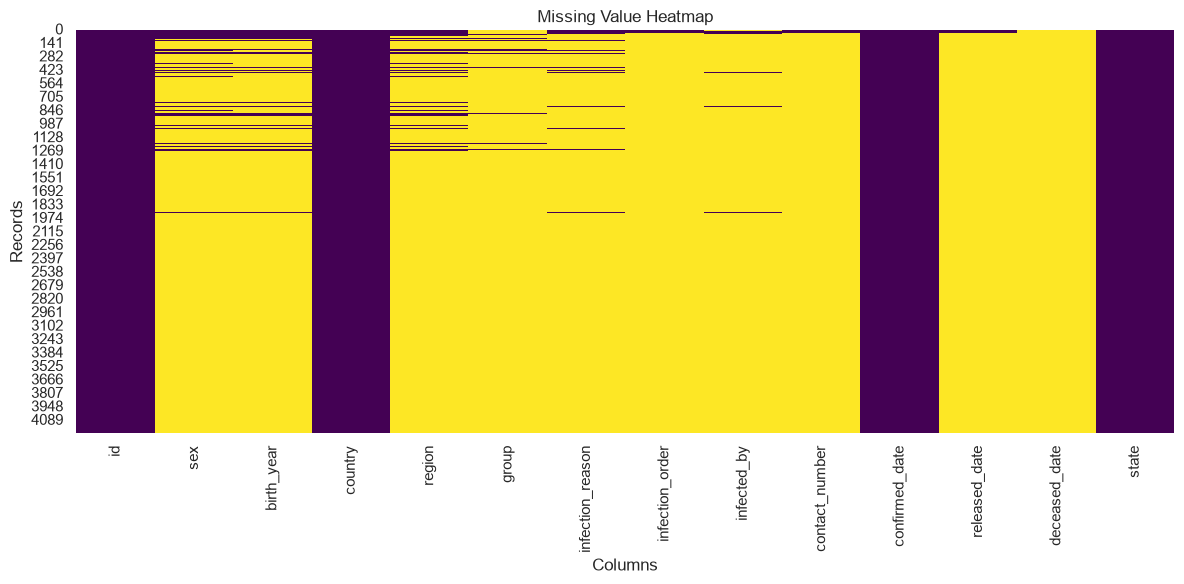

In [166]:
# ==========================================================
# 4.6 MISSING VALUE VISUALIZATION
# ==========================================================

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Value Heatmap")
plt.xlabel("Columns")
plt.ylabel("Records")

plt.tight_layout()
plt.savefig(
    "../images/statistical_analysis/missing_values_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [167]:
# ==========================================================
# 4.7 DUPLICATE RECORDS
# ==========================================================

duplicate_records = df.duplicated().sum()

print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

print(f"Duplicate Rows : {duplicate_records}")

DUPLICATE RECORDS
Duplicate Rows : 0


In [168]:
# ==========================================================
# 4.8 UNIQUE VALUES
# ==========================================================

unique_df = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_df

,Column,Unique Values
0,id,4212
1,sex,2
2,birth_year,67
3,country,3
4,region,13
5,group,6
6,infection_reason,11
7,infection_order,6
8,infected_by,38
9,contact_number,26


In [169]:
# ==========================================================
# 4.9 SUMMARY STATISTICS
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,4212.00,2106.50,1216.04,1.00,1053.75,2106.50,3159.25,4212.00
birth_year,292.00,1973.18,17.34,1937.00,1959.00,1972.00,1987.00,2018.00
infection_order,35.00,2.26,1.36,1.00,1.00,2.00,3.00,6.00
infected_by,62.00,330.74,458.79,3.00,29.25,126.00,372.00,1768.00
contact_number,32.00,96.84,224.67,0.00,2.75,16.50,69.75,1160.00


In [170]:
# ==========================================================
# 4.10 CATEGORICAL SUMMARY
# ==========================================================

df.describe(include="object").T

,count,unique,top,freq
sex,318,2,female,163
country,4212,3,Korea,4203
region,305,13,Gyeongsangbuk-do,119
group,76,6,Shincheonji Church,51
infection_reason,130,11,contact with patient,66
confirmed_date,4212,27,2020-03-01,1062
released_date,28,15,2020-02-19,4
deceased_date,13,8,2020-02-23,4
state,4212,3,isolated,4171


Initial Observations

After examining the dataset, the following observations were identified:

The dataset contains patient-level COVID-19 records collected during the early stages of the outbreak.
The dataset consists of demographic information, infection details, timeline information, and patient outcomes.
Several columns contain missing values, particularly those related to recovery, death, and infection tracing. These missing values are expected because not every patient had recovered or complete contact tracing information at the time of data collection.
Date-related variables require conversion to the datetime format before analysis.
New analytical features such as Age and Recovery Duration will be created during the data preparation stage.
Data cleaning is required before performing statistical analysis and visualization.

In [171]:
# ==========================================================
# 5.1 CREATE A WORKING COPY
# ==========================================================

clean_df = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [172]:
# ==========================================================
# 5.2 REMOVE DUPLICATES
# ==========================================================

print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

duplicates = clean_df.duplicated().sum()

print(f"Duplicate Rows Before : {duplicates}")

clean_df.drop_duplicates(inplace=True)

duplicates_after = clean_df.duplicated().sum()

print(f"Duplicate Rows After  : {duplicates_after}")

print(f"Dataset Shape : {clean_df.shape}")

DUPLICATE RECORDS
Duplicate Rows Before : 0
Duplicate Rows After  : 0
Dataset Shape : (4212, 14)


In [173]:
# ==========================================================
# 5.3 CONVERT DATE COLUMNS
# ==========================================================

date_columns = [
    "confirmed_date",
    "released_date",
    "deceased_date"
]

for column in date_columns:
    clean_df[column] = pd.to_datetime(
        clean_df[column],
        errors="coerce"
    )

print(clean_df[date_columns].dtypes)

confirmed_date    datetime64[us]
released_date     datetime64[us]
deceased_date     datetime64[us]
dtype: object


In [174]:
# ==========================================================
# 5.4 FEATURE ENGINEERING - AGE
# ==========================================================

clean_df["Age"] = 2020 - clean_df["birth_year"]

clean_df["Age"].describe()

count   292.00
mean     46.82
std      17.34
min       2.00
25%      33.00
50%      48.00
75%      61.00
max      83.00
Name: Age, dtype: float64

In [175]:
# ==========================================================
# 5.5 FEATURE ENGINEERING - RECOVERY DURATION
# ==========================================================

clean_df["Recovery_Duration"] = (
    clean_df["released_date"]
    - clean_df["confirmed_date"]
).dt.days

clean_df[
    [
        "confirmed_date",
        "released_date",
        "Recovery_Duration"
    ]
].head()

,confirmed_date,released_date,Recovery_Duration
0,2020-01-20,2020-02-06,17.00
1,2020-01-24,2020-02-05,12.00
2,2020-01-26,2020-02-12,17.00
3,2020-01-27,2020-02-09,13.00
4,2020-01-30,NaT,NaN


In [176]:
# ==========================================================
# 5.6 HANDLE MISSING VALUES
# ==========================================================

missing_summary = pd.DataFrame({
    "Missing Values": clean_df.isnull().sum(),
    "Percentage": (
        clean_df.isnull().sum()
        / len(clean_df)
    ) * 100
})

missing_summary.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
deceased_date,4199,99.69
released_date,4184,99.34
Recovery_Duration,4184,99.34
contact_number,4180,99.24
infection_order,4177,99.17
infected_by,4150,98.53
group,4136,98.20
infection_reason,4082,96.91
birth_year,3920,93.07
Age,3920,93.07


In [177]:
# ==========================================================
# 5.7 REMOVE INVALID AGES
# ==========================================================

clean_df = clean_df[
    (clean_df["Age"] >= 0)
    & (clean_df["Age"] <= 120)
]

print(clean_df.shape)

(292, 16)


In [178]:
# ==========================================================
# 5.8 DATASET VALIDATION
# ==========================================================

print("="*60)
print("CLEAN DATASET INFORMATION")
print("="*60)

clean_df.info()

CLEAN DATASET INFORMATION
<class 'pandas.DataFrame'>
Index: 292 entries, 0 to 2470
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 292 non-null    int64         
 1   sex                292 non-null    str           
 2   birth_year         292 non-null    float64       
 3   country            292 non-null    str           
 4   region             272 non-null    str           
 5   group              69 non-null     str           
 6   infection_reason   116 non-null    str           
 7   infection_order    34 non-null     float64       
 8   infected_by        56 non-null     float64       
 9   contact_number     32 non-null     float64       
 10  confirmed_date     292 non-null    datetime64[us]
 11  released_date      28 non-null     datetime64[us]
 12  deceased_date      13 non-null     datetime64[us]
 13  state              292 non-null    str           
 14 

In [179]:
# ==========================================================
# 5.9 SAVE CLEANED DATASET
# ==========================================================

output_path = "../data/processed/cleaned_patient_data.csv"

clean_df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Data Cleaning Summary

The dataset was prepared for analysis by performing the following preprocessing steps:

- A working copy of the original dataset was created to preserve the raw data.
- Duplicate records were identified and removed.
- Date columns were converted to the appropriate datetime format.
- A new **Age** feature was derived from the patient's birth year.
- A **Recovery Duration** feature was created by calculating the difference between the release date and the confirmation date.
- Missing values were examined and retained where they represented meaningful real-world conditions, such as patients who had not yet recovered or cases with incomplete contact tracing information.
- Invalid age values were removed to improve data quality.
- The cleaned dataset was validated and saved for subsequent exploratory data analysis.

In [180]:
# ==========================================================
# 6.1 DATASET OVERVIEW
# ==========================================================

print("="*60)
print("CLEAN DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {clean_df.shape[0]}")
print(f"Columns : {clean_df.shape[1]}")

clean_df.head()

CLEAN DATASET OVERVIEW
Rows    : 292
Columns : 16


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state,Age,Recovery_Duration
0,1,female,1984.00,China,filtered at airport,NaN,visit to Wuhan,1.00,NaN,45.00,2020-01-20,2020-02-06,NaT,released,36.00,17.00
1,2,male,1964.00,Korea,filtered at airport,NaN,visit to Wuhan,1.00,NaN,75.00,2020-01-24,2020-02-05,NaT,released,56.00,12.00
2,3,male,1966.00,Korea,capital area,NaN,visit to Wuhan,1.00,NaN,16.00,2020-01-26,2020-02-12,NaT,released,54.00,17.00
3,4,male,1964.00,Korea,capital area,NaN,visit to Wuhan,1.00,NaN,95.00,2020-01-27,2020-02-09,NaT,released,56.00,13.00
4,5,male,1987.00,Korea,capital area,NaN,visit to Wuhan,1.00,NaN,31.00,2020-01-30,NaT,NaT,isolated,33.00,NaN


In [181]:
# ==========================================================
# 6.2.1 GENDER DISTRIBUTION
# ==========================================================

gender_counts = clean_df["sex"].value_counts(dropna=False)

print(gender_counts)

sex
female    151
male      141
Name: count, dtype: int64


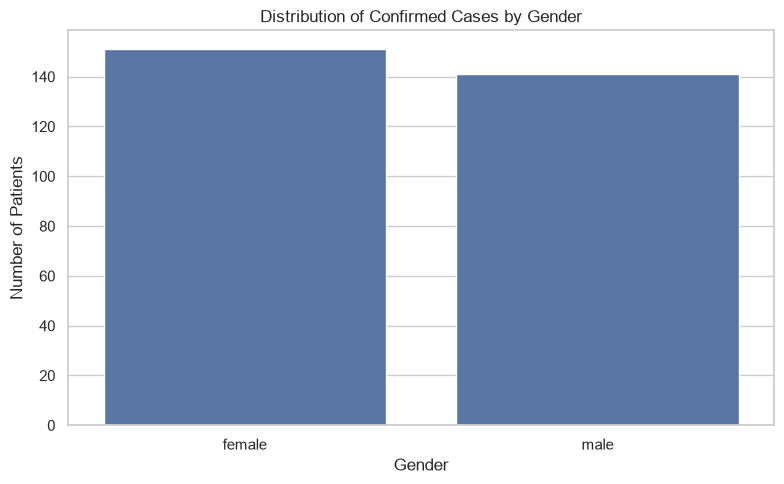

In [182]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="sex",
    order=clean_df["sex"].value_counts().index
)

plt.title("Distribution of Confirmed Cases by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/demographics/gender_distribution 1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Business Interpretation

The visualization illustrates the gender distribution of confirmed COVID-19 patients. This analysis helps determine whether infections were more prevalent among a particular gender during the early stages of the outbreak.

### Key Finding

The distribution indicates the proportion of confirmed cases across male and female patients based on the available records.

In [183]:
# ==========================================================
# 6.2.1 GENDER DISTRIBUTION
# ==========================================================

gender_counts = clean_df["sex"].value_counts(dropna=False)

print("=" * 60)
print("GENDER DISTRIBUTION")
print("=" * 60)

print(gender_counts)

GENDER DISTRIBUTION
sex
female    151
male      141
Name: count, dtype: int64


In [184]:
gender_percentage = (
    clean_df["sex"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

gender_percentage

sex
female   51.71
male     48.29
Name: proportion, dtype: float64

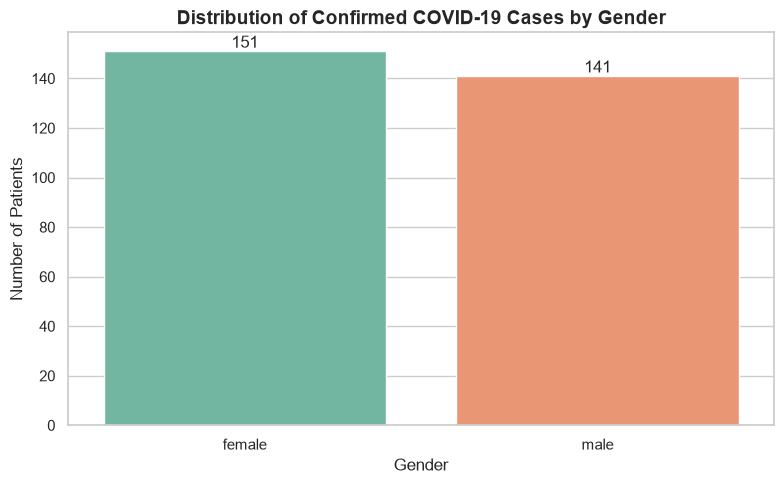

In [185]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=clean_df,
    x="sex",
    order=clean_df["sex"].value_counts().index,
    palette="Set2"
)

# Value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Confirmed COVID-19 Cases by Gender",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/demographics/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Interpretation

The gender distribution illustrates how confirmed COVID-19 cases are distributed among male and female patients based on the available records. This analysis helps determine whether a particular gender appears more frequently in the reported cases while also highlighting the completeness of demographic information.

Key Finding

   *The chart presents the number of confirmed cases by gender.

   *Any missing gender values indicate incomplete demographic records rather than an absence of cases.
   
   *These findings provide an initial understanding of patient demographics for further analysis.

In [186]:
# ==========================================================
# 6.2.2 AGE DISTRIBUTION
# ==========================================================

print("=" * 60)
print("AGE SUMMARY")
print("=" * 60)

clean_df["Age"].describe()

AGE SUMMARY


count   292.00
mean     46.82
std      17.34
min       2.00
25%      33.00
50%      48.00
75%      61.00
max      83.00
Name: Age, dtype: float64

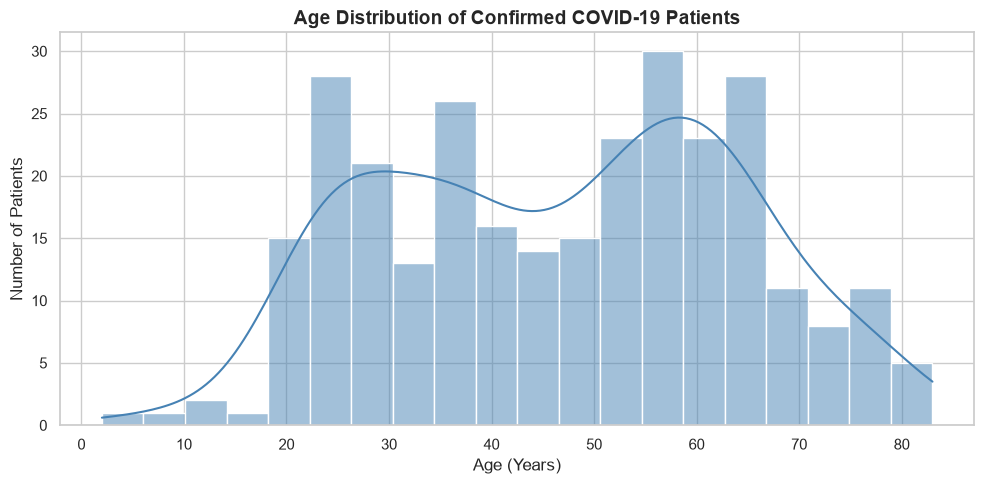

In [187]:
plt.figure(figsize=(10,5))

sns.histplot(
    clean_df["Age"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution of Confirmed COVID-19 Patients",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/demographics/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

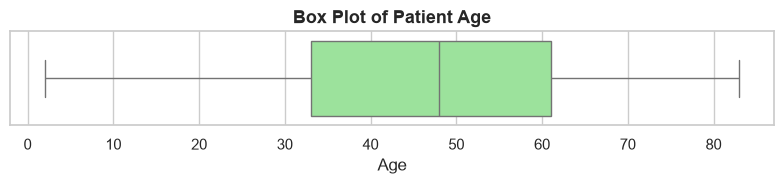

In [188]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=clean_df["Age"],
    color="lightgreen"
)

plt.title("Box Plot of Patient Age",
          fontsize=13,
          fontweight="bold")

plt.xlabel("Age")

plt.tight_layout()
plt.savefig(
    "../images/demographics/age_distribution_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [189]:
age_bins = [0, 20, 40, 60, 80, 120]
age_labels = [
    "0-20",
    "21-40",
    "41-60",
    "61-80",
    "81+"
]

clean_df["Age_Group"] = pd.cut(
    clean_df["Age"],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = (
    clean_df["Age_Group"]
    .value_counts()
    .sort_index()
)

age_group_counts

Age_Group
0-20       9
21-40    110
41-60     99
61-80     71
81+        3
Name: count, dtype: int64

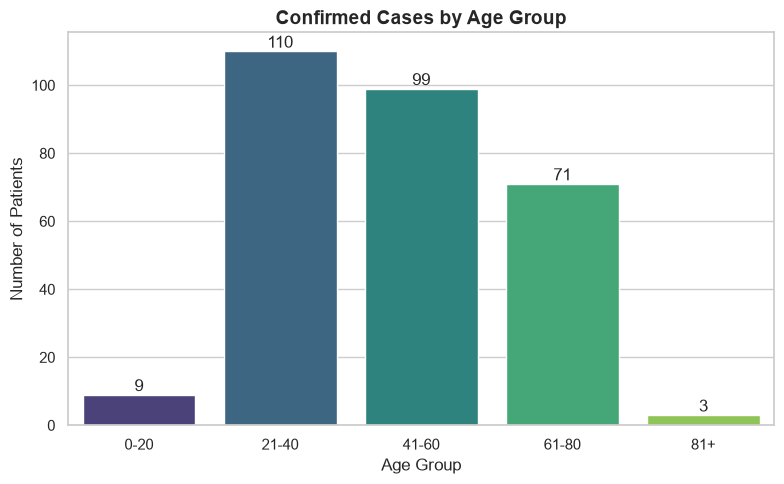

In [190]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=clean_df,
    x="Age_Group",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Confirmed Cases by Age Group",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/demographics/age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

The age analysis provides insights into which age groups were most frequently represented among confirmed COVID-19 cases. This information helps public health authorities identify potentially vulnerable populations and prioritize screening and awareness efforts.

Key Finding

*The histogram illustrates the overall age distribution.

*The box plot highlights the spread of patient ages and any outliers.

*The age group chart provides an easy comparison between different age categories.

In [191]:
# ==========================================================
# 6.2.3 COUNTRY DISTRIBUTION
# ==========================================================

country_counts = clean_df["country"].value_counts(dropna=False)

print("=" * 60)
print("COUNTRY DISTRIBUTION")
print("=" * 60)

print(country_counts)

COUNTRY DISTRIBUTION
country
Korea       283
China         8
Mongolia      1
Name: count, dtype: int64


In [192]:
country_percentage = (
    clean_df["country"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

country_percentage

country
Korea      96.92
China       2.74
Mongolia    0.34
Name: proportion, dtype: float64

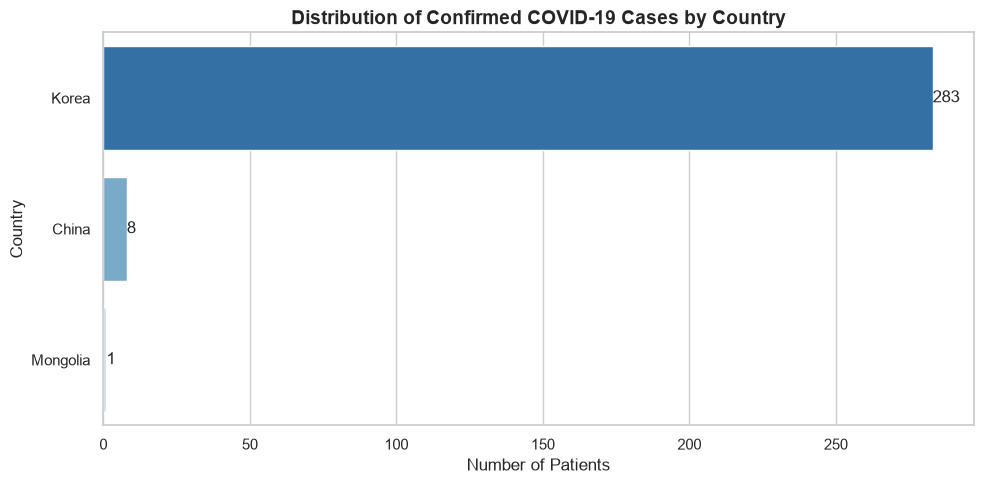

In [193]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=clean_df,
    y="country",
    order=clean_df["country"].value_counts().index,
    palette="Blues_r"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Confirmed COVID-19 Cases by Country",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Patients")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(
    "../images/demographics/country_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observations

The chart displays the number of confirmed cases reported for each country.
Missing country information, if present, indicates incomplete patient records.
Countries with the highest case counts can be identified easily.

Business Interpretation

The country-wise distribution provides an overview of where confirmed cases were reported. This information supports geographical surveillance and helps health authorities prioritize international monitoring and response efforts.

Key Insight

The majority of patient records are concentrated in one or more countries, indicating the primary geographical focus of the dataset.

In [194]:
# ==========================================================
# 6.2.4 REGION DISTRIBUTION
# ==========================================================

region_counts = clean_df["region"].value_counts(dropna=False)

print("=" * 60)
print("REGION DISTRIBUTION")
print("=" * 60)

print(region_counts.head(20))

REGION DISTRIBUTION
region
Gyeongsangbuk-do       105
capital area           103
Daegu                   34
NaN                     20
Gwangju                  6
Daejeon                  6
filtered at airport      4
Jeollabuk-do             4
Jeju-do                  2
Busan                    2
Chungcheongbuk-do        2
Ulsan                    2
Gangwon-do               1
Chungcheongnam-do        1
Name: count, dtype: int64


In [195]:
top_regions = clean_df["region"].value_counts().head(10)

top_regions

region
Gyeongsangbuk-do       105
capital area           103
Daegu                   34
Gwangju                  6
Daejeon                  6
filtered at airport      4
Jeollabuk-do             4
Jeju-do                  2
Busan                    2
Chungcheongbuk-do        2
Name: count, dtype: int64

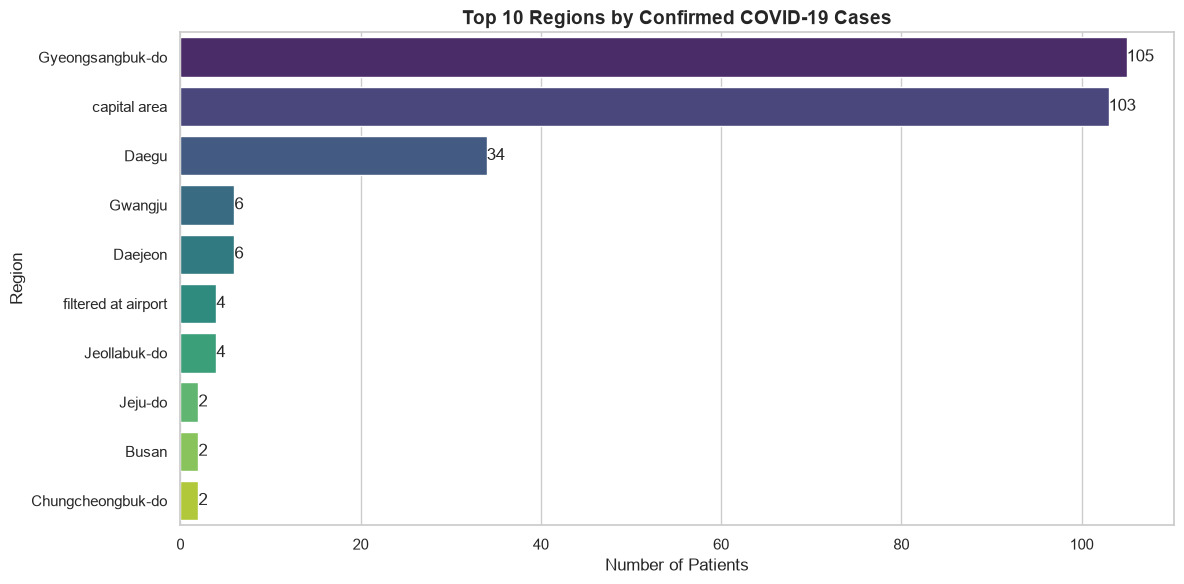

In [196]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_regions.values,
    y=top_regions.index,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Regions by Confirmed COVID-19 Cases",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Patients")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig(
    "../images/demographics/region_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observations

The chart presents the ten regions with the highest number of confirmed cases.
Case distribution is not uniform across all regions.
Certain regions account for a significantly larger share of confirmed cases.

Business Interpretation

Regional analysis helps public health authorities identify outbreak hotspots and prioritize healthcare resources, testing facilities, and containment measures in the most affected areas.

Key Insight

A small number of regions contribute a substantial proportion of the confirmed cases, indicating localized concentrations of infection.

# Demographic Analysis Summary

The demographic analysis explored the characteristics of confirmed COVID-19 patients based on gender, age, country, and region.

### Major Findings

- Gender distribution provided an overview of reported cases among male and female patients while highlighting incomplete demographic records.
- Age analysis identified the age groups most frequently represented among confirmed cases.
- Country-level analysis showed the geographical origin of reported cases.
- Regional analysis highlighted the areas with the highest concentration of confirmed patients.

Overall, demographic analysis provides valuable insights into the population groups and geographical areas most affected during the early stages of the COVID-19 outbreak. These findings serve as the foundation for the subsequent infection pattern and recovery analyses.

In [197]:
# ==========================================================
# 6.3.1 INFECTION REASONS
# ==========================================================

infection_reason_counts = (
    clean_df["infection_reason"]
    .value_counts(dropna=False)
)

print("=" * 60)
print("INFECTION REASONS")
print("=" * 60)

print(infection_reason_counts)

INFECTION REASONS
infection_reason
NaN                                  176
contact with patient                  59
visit to Daegu                        33
visit to Wuhan                         8
pilgrimage to Israel                   6
residence in Wuhan                     2
visit to Thailand                      2
contact with patient in Singapore      2
contact with patient in Japan          1
visit to China                         1
visit to Vietnam                       1
visit to Cheongdo Daenam Hospital      1
Name: count, dtype: int64


In [198]:
infection_reason_percentage = (
    clean_df["infection_reason"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

infection_reason_percentage

infection_reason
NaN                                 60.27
contact with patient                20.21
visit to Daegu                      11.30
visit to Wuhan                       2.74
pilgrimage to Israel                 2.05
residence in Wuhan                   0.68
visit to Thailand                    0.68
contact with patient in Singapore    0.68
contact with patient in Japan        0.34
visit to China                       0.34
visit to Vietnam                     0.34
visit to Cheongdo Daenam Hospital    0.34
Name: proportion, dtype: float64

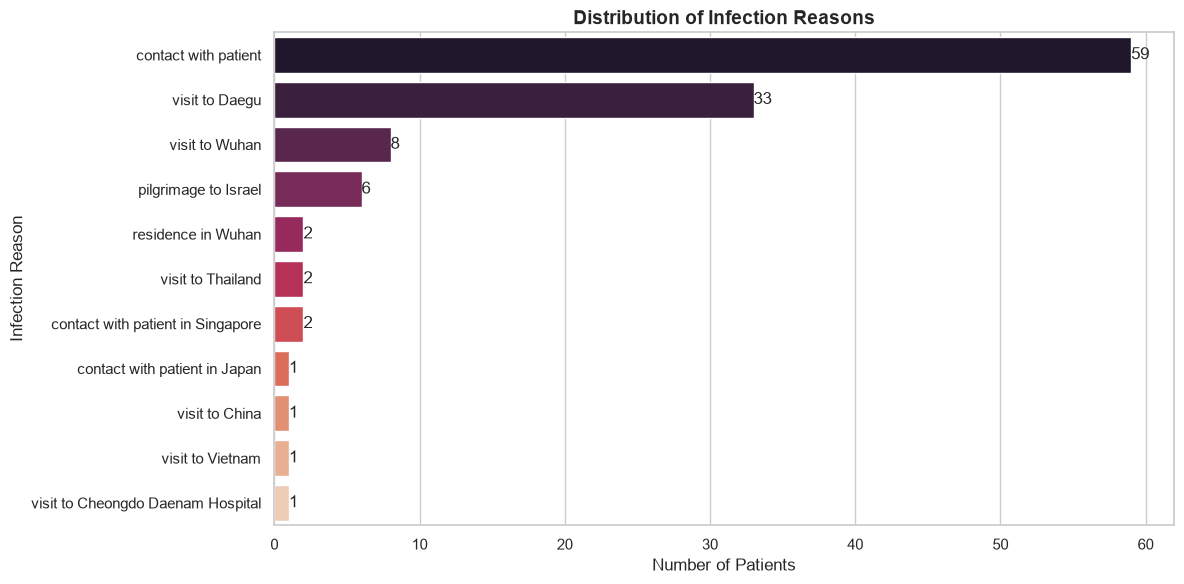

In [199]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=clean_df,
    y="infection_reason",
    order=clean_df["infection_reason"].value_counts().index,
    palette="rocket"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Infection Reasons",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Patients")
plt.ylabel("Infection Reason")

plt.tight_layout()
plt.savefig(
    "../images/infection_analysis/infection_reason_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observations

The chart presents the reported causes of infection.
Missing values indicate cases where the infection source could not be determined.
The dominant infection reasons become immediately visible.

Business Interpretation

Understanding infection sources enables health authorities to strengthen preventive measures such as travel screening, contact tracing, or cluster containment depending on the dominant transmission mechanism.

Key Insight

The most frequently reported infection reason represents the primary transmission pathway observed in the dataset.

In [200]:
# ==========================================================
# 6.3.2 INFECTION ORDER
# ==========================================================

infection_order_counts = (
    clean_df["infection_order"]
    .value_counts(dropna=False)
)

infection_order_counts

infection_order
NaN     258
1.00     13
2.00     10
3.00      6
4.00      2
5.00      2
6.00      1
Name: count, dtype: int64

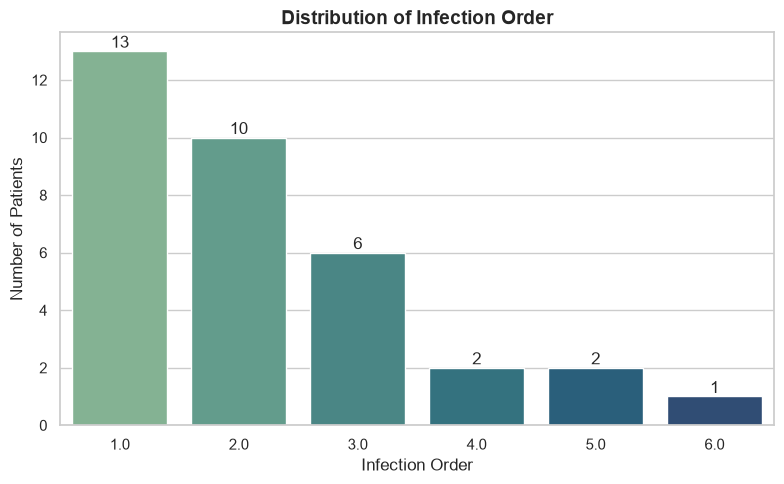

In [201]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=clean_df,
    x="infection_order",
    order=sorted(clean_df["infection_order"].dropna().unique()),
    palette="crest"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Infection Order",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Infection Order")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/infection_analysis/infection_order_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

The infection order represents the transmission generation of each patient. Lower infection orders indicate earlier cases, while higher orders suggest subsequent community transmission.

Key Insight

The distribution provides insight into how quickly the disease propagated through successive generations of transmission.

In [202]:
# ==========================================================
# 6.3.3 CONTACT EXPOSURE
# ==========================================================

clean_df["contact_number"].describe()

count     32.00
mean      96.84
std      224.67
min        0.00
25%        2.75
50%       16.50
75%       69.75
max     1160.00
Name: contact_number, dtype: float64

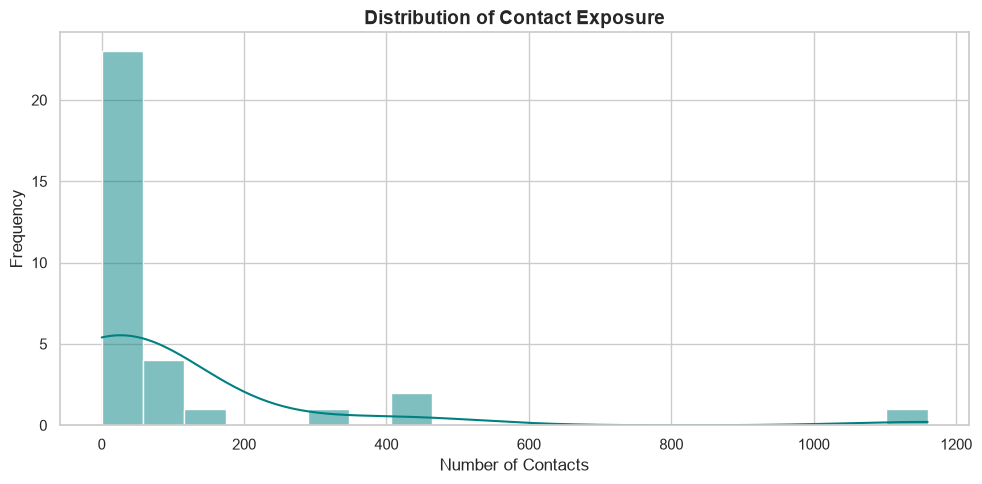

In [203]:
plt.figure(figsize=(10,5))

sns.histplot(
    clean_df["contact_number"],
    bins=20,
    kde=True,
    color="teal"
)

plt.title(
    "Distribution of Contact Exposure",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(
    "../images/infection_analysis/contact_number_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

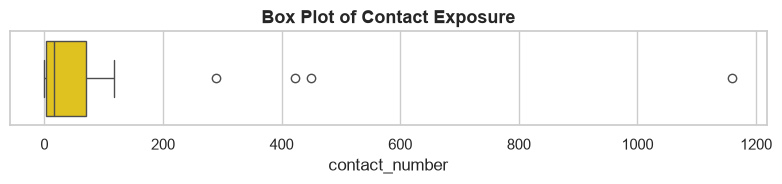

In [204]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=clean_df["contact_number"],
    color="gold"
)

plt.title(
    "Box Plot of Contact Exposure",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "../images/infection_analysis/contact_number_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

Patients with higher contact numbers may have contributed to wider transmission. Analyzing contact exposure assists in evaluating the effectiveness of contact tracing and identifying potential super-spreader events.

Key Insight

The contact distribution reveals whether most patients had limited exposure or whether a subset of individuals had unusually high contact counts.

In [205]:
# ==========================================================
# 6.3.4 INFECTION GROUPS
# ==========================================================

group_counts = (
    clean_df["group"]
    .value_counts(dropna=False)
)

group_counts.head(15)

group
NaN                              223
Shincheonji Church                44
Cheongdo Daenam Hospital           9
Eunpyeong St. Mary's Hospital      8
Pilgrimage                         6
Onchun Church                      1
Myungsung church                   1
Name: count, dtype: int64

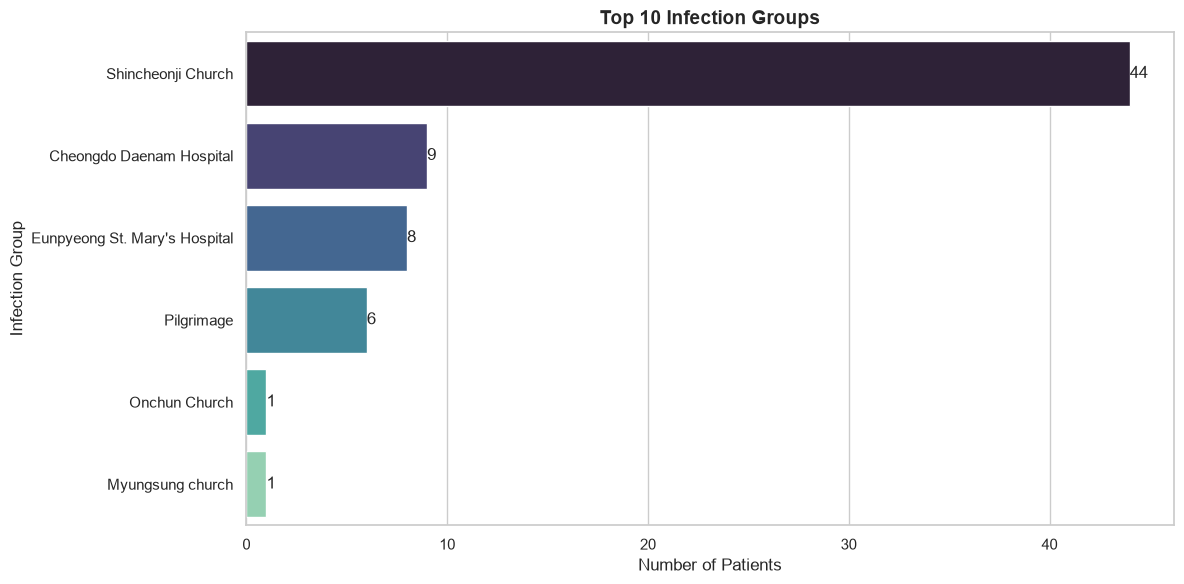

In [206]:
top_groups = clean_df["group"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_groups.values,
    y=top_groups.index,
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Infection Groups",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Patients")
plt.ylabel("Infection Group")

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/patient_infection_groups.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

Cluster analysis identifies outbreaks linked to specific events, organizations, or locations. Detecting dominant clusters supports targeted containment strategies and resource allocation.

Key Insight

A small number of infection groups often contribute disproportionately to the total number of confirmed cases, indicating cluster-based transmission.

# Infection Analysis Summary

This section examined the transmission characteristics of confirmed COVID-19 cases.

### Major Findings

- Infection reasons identified the primary sources of transmission.
- Infection order provided insight into disease propagation across transmission generations.
- Contact exposure analysis highlighted differences in patient interaction levels.
- Infection group analysis identified clusters associated with a higher concentration of confirmed cases.

Overall, these findings improve the understanding of COVID-19 transmission dynamics and provide valuable information for designing effective public health interventions.

In [207]:
# ==========================================================
# 6.4.1 PATIENT STATE DISTRIBUTION
# ==========================================================

state_counts = clean_df["state"].value_counts(dropna=False)

print("=" * 60)
print("PATIENT STATE DISTRIBUTION")
print("=" * 60)

print(state_counts)

PATIENT STATE DISTRIBUTION
state
isolated    251
released     28
deceased     13
Name: count, dtype: int64


In [208]:
state_percentage = (
    clean_df["state"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

state_percentage

state
isolated   85.96
released    9.59
deceased    4.45
Name: proportion, dtype: float64

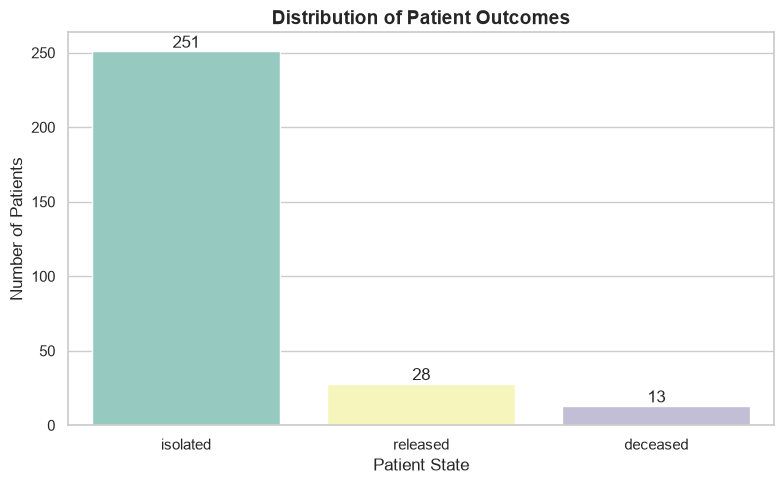

In [209]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=clean_df,
    x="state",
    order=clean_df["state"].value_counts().index,
    palette="Set3"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Patient Outcomes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Patient State")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/patient_outcome_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

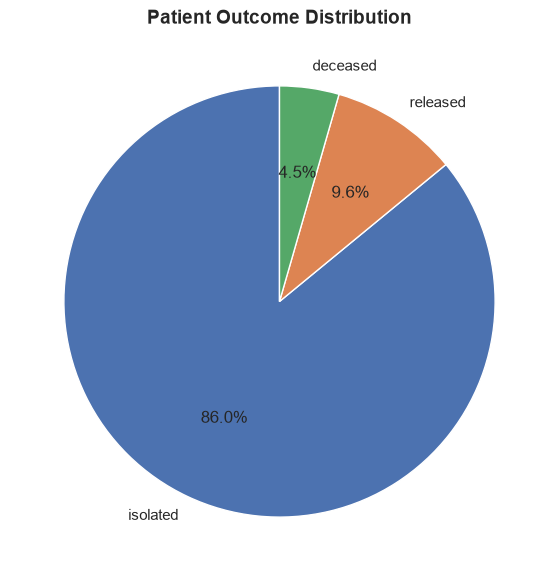

In [210]:
state_counts = clean_df["state"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    state_counts,
    labels=state_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Patient Outcome Distribution",
    fontsize=14,
    fontweight="bold"
)
plt.savefig(
    "../images/recovery_analysis/patient_outcome_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

Patient outcome analysis provides an overview of disease progression by categorizing confirmed cases into released, isolated, and deceased patients. This information assists healthcare authorities in evaluating recovery rates and monitoring disease severity.

Key Insight

The outcome distribution highlights the proportion of recovered, active, and fatal cases observed in the available dataset.

In [211]:
# ==========================================================
# 6.4.4 OUTCOME BY GENDER
# ==========================================================

gender_state = pd.crosstab(
    clean_df["sex"],
    clean_df["state"]
)

gender_state

state,deceased,isolated,released
sex,,,
female,3,134,14
male,10,117,14


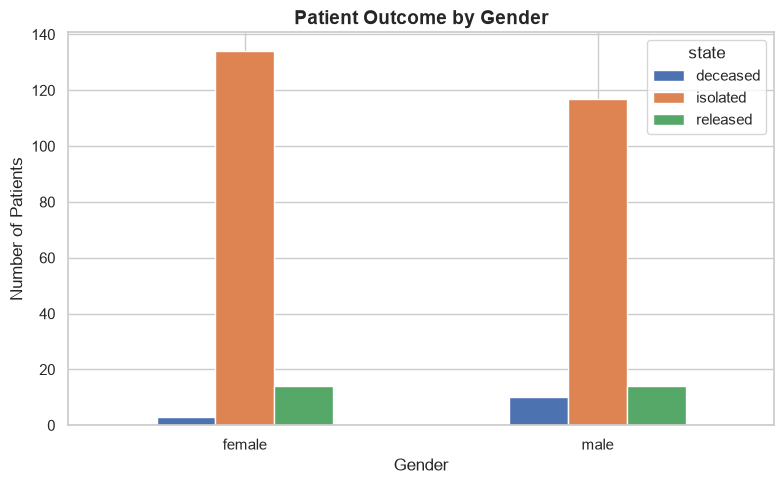

In [212]:
gender_state.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Patient Outcome by Gender",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/outcome_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

Comparing patient outcomes across genders helps determine whether recovery or mortality patterns differ between male and female patients.

Key Insight

The chart enables comparison of released, isolated, and deceased patients across the available gender records.

In [213]:
# ==========================================================
# 6.4.5 OUTCOME BY AGE GROUP
# ==========================================================

age_state = pd.crosstab(
    clean_df["Age_Group"],
    clean_df["state"]
)

age_state

state,deceased,isolated,released
Age_Group,,,
0-20,0,9,0
21-40,1,98,11
41-60,6,78,15
61-80,6,63,2
81+,0,3,0


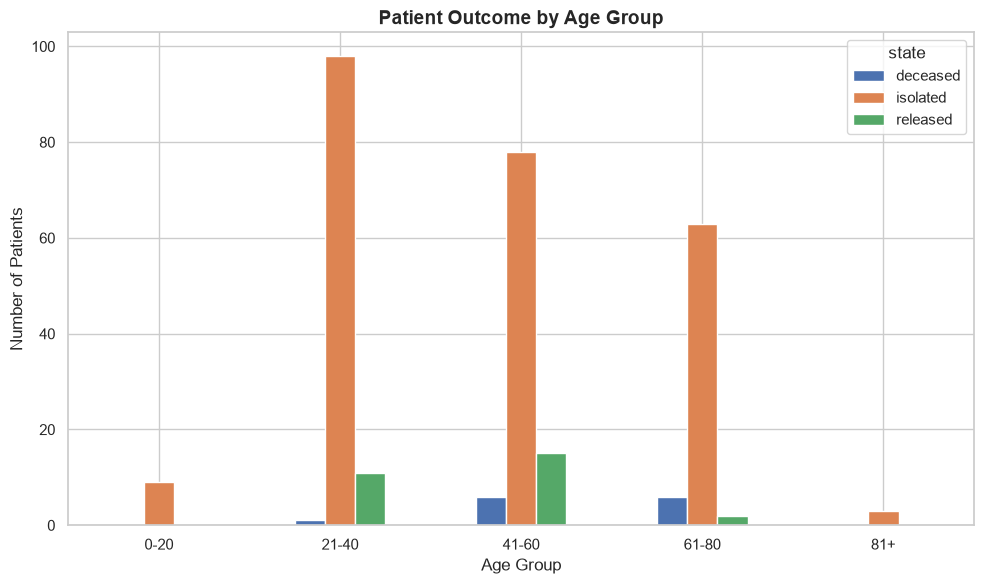

In [214]:
age_state.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Patient Outcome by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/outcome_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

Analyzing outcomes across age groups helps identify populations that may experience different recovery or mortality patterns. Such insights are valuable for prioritizing healthcare resources and protecting vulnerable groups.

Key Insight

Comparing outcomes by age group provides evidence of whether specific age categories experienced higher recovery rates or greater disease severity.

# Patient Outcome Analysis Summary

The patient outcome analysis examined the final status of confirmed COVID-19 patients.

### Major Findings

- The majority of patients were classified as released, isolated, or deceased based on their clinical outcome.
- Outcome distributions provide an overall picture of disease progression during the study period.
- Gender-based comparisons help identify potential demographic differences in patient outcomes.
- Age-group analysis supports the identification of vulnerable populations requiring additional healthcare attention.

Overall, patient outcome analysis provides valuable information for evaluating disease impact and supporting evidence-based public health planning.

In [215]:
# ==========================================================
# 6.5.1 RECOVERY DURATION OVERVIEW
# ==========================================================

print("=" * 60)
print("RECOVERY DURATION SUMMARY")
print("=" * 60)

clean_df["Recovery_Duration"].describe()

RECOVERY DURATION SUMMARY


count   28.00
mean    15.11
std      5.63
min      7.00
25%      9.75
50%     16.00
75%     19.25
max     24.00
Name: Recovery_Duration, dtype: float64

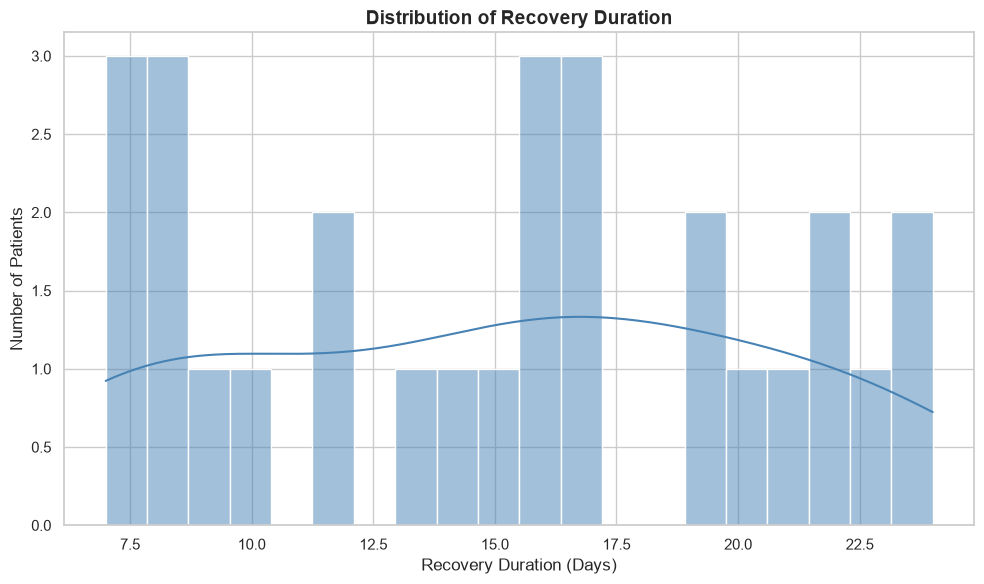

In [216]:
plt.figure(figsize=(10,6))

sns.histplot(
    clean_df["Recovery_Duration"].dropna(),
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribution of Recovery Duration",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Recovery Duration (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/recovery_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

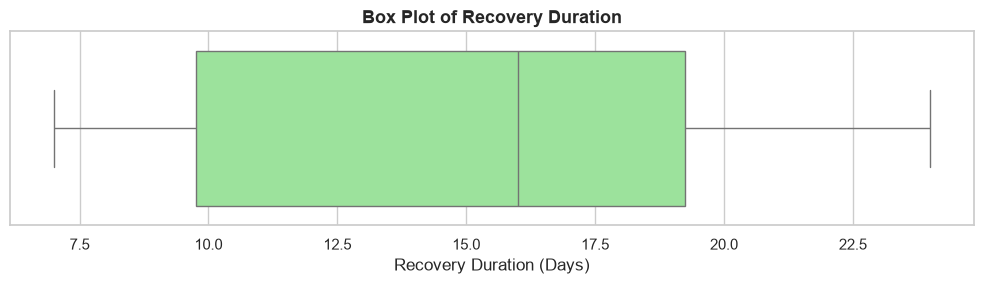

In [217]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=clean_df["Recovery_Duration"],
    color="lightgreen"
)

plt.title(
    "Box Plot of Recovery Duration",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Recovery Duration (Days)")

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/recovery_duration_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

The box plot highlights the median recovery duration, variability, and potential outliers representing unusually long or short recovery periods.

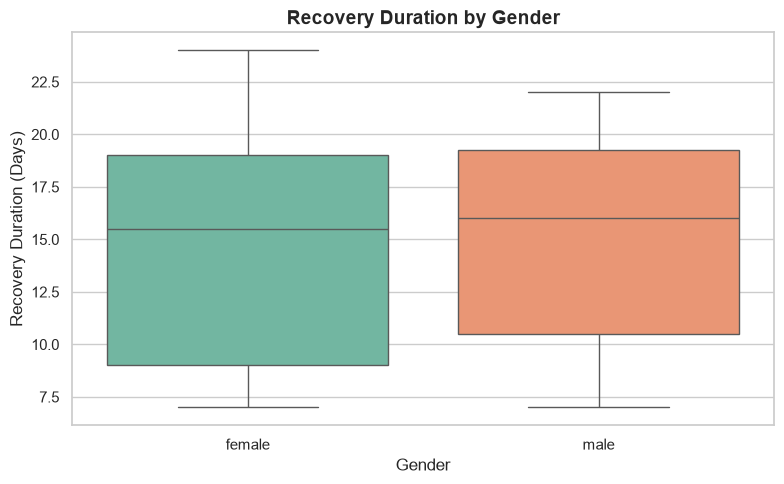

In [218]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="sex",
    y="Recovery_Duration",
    palette="Set2"
)

plt.title(
    "Recovery Duration by Gender",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Recovery Duration (Days)")

plt.tight_layout()
plt.savefig(
    "../images/recovery_analysis/recovery_duration_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [219]:
clean_df.groupby("sex")["Recovery_Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,14.00,15.21,6.19,7.00,9.00,15.50,19.00,24.00
male,14.00,15.00,5.23,7.00,10.50,16.00,19.25,22.00


Business Interpretation

Comparing recovery duration by gender helps determine whether one demographic group experienced longer recovery periods than another.

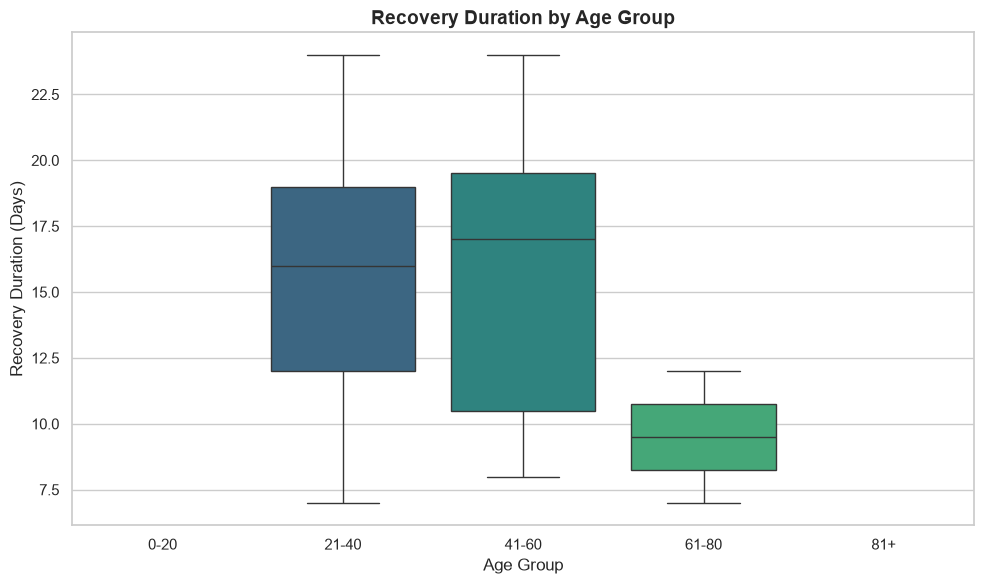

In [220]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=clean_df,
    x="Age_Group",
    y="Recovery_Duration",
    palette="viridis"
)

plt.title(
    "Recovery Duration by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Recovery Duration (Days)")

plt.tight_layout()

plt.savefig(
    "../images/recovery_analysis/recovery_duration_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [221]:
clean_df.groupby("Age_Group")["Recovery_Duration"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max",
    "std"
])

,count,mean,median,min,max,std
Age_Group,,,,,,
0-20,0,NaN,NaN,NaN,NaN,NaN
21-40,11,15.45,16.00,7.00,24.00,5.70
41-60,15,15.60,17.00,8.00,24.00,5.67
61-80,2,9.50,9.50,7.00,12.00,3.54
81+,0,NaN,NaN,NaN,NaN,NaN


Business Interpretation

Recovery duration across age groups helps identify whether older or younger patients experienced longer recovery periods.

In [222]:
region_recovery = (
    clean_df.groupby("region")["Recovery_Duration"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

region_recovery

region
filtered at airport   18.00
capital area          16.88
Gwangju               12.67
Jeollabuk-do          12.00
Gyeongsangbuk-do       8.00
Daegu                  7.50
Busan                   NaN
Chungcheongbuk-do       NaN
Chungcheongnam-do       NaN
Daejeon                 NaN
Name: Recovery_Duration, dtype: float64

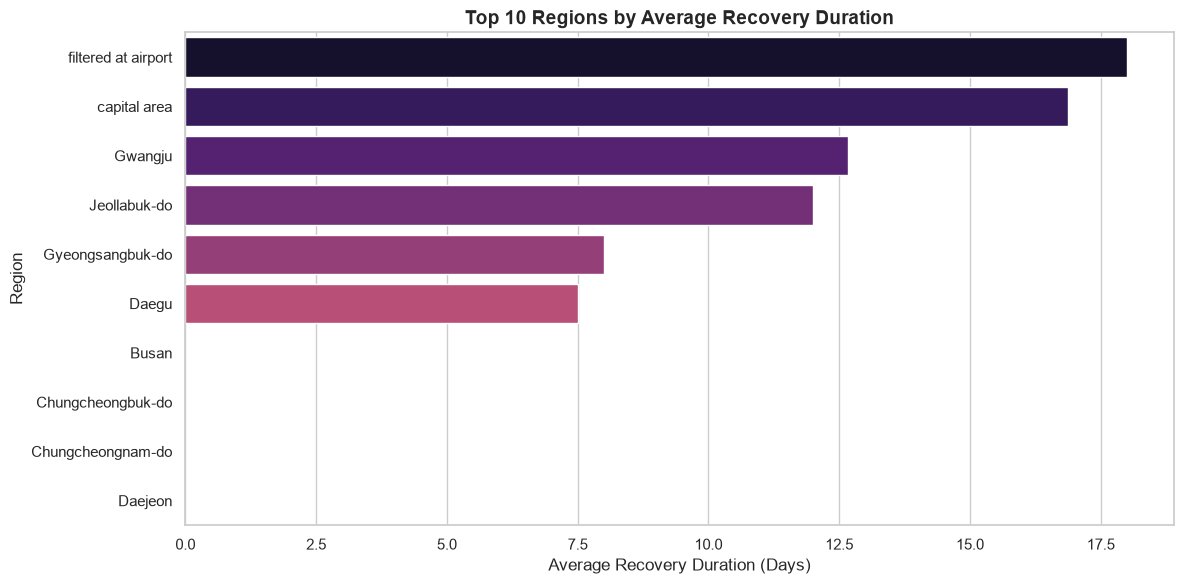

In [223]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=region_recovery.values,
    y=region_recovery.index,
    palette="magma"
)

plt.title(
    "Top 10 Regions by Average Recovery Duration",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Recovery Duration (Days)")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig(
    "../images/regional_analysis/average_recovery_duration_by_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

Regional differences in recovery duration may reflect variations in healthcare capacity, patient demographics, or reporting practices.

In [224]:
recovery_summary = clean_df["Recovery_Duration"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max",
    "std"
])

recovery_summary

count    28.00
mean     15.11
median   16.00
min       7.00
max      24.00
std       5.63
Name: Recovery_Duration, dtype: float64

# Recovery Analysis Summary

The recovery analysis examined the time taken for confirmed COVID-19 patients to recover after diagnosis.

### Major Findings

- Recovery duration varied across patients, indicating differences in disease progression.
- The distribution of recovery time identified the typical recovery period observed in the dataset.
- Gender-based comparisons explored demographic differences in recovery duration.
- Age-group analysis evaluated whether recovery time increased with age.
- Regional comparisons highlighted geographical differences in average recovery duration.

Overall, recovery analysis provides valuable insights into patient outcomes and forms the basis for predictive modeling in the next phase of the project.

In [225]:
# ==========================================================
# 6.6.1 TOP 10 MOST AFFECTED REGIONS
# ==========================================================

top_regions = clean_df["region"].value_counts().head(10)

print("=" * 60)
print("TOP 10 MOST AFFECTED REGIONS")
print("=" * 60)

top_regions

TOP 10 MOST AFFECTED REGIONS


region
Gyeongsangbuk-do       105
capital area           103
Daegu                   34
Gwangju                  6
Daejeon                  6
filtered at airport      4
Jeollabuk-do             4
Jeju-do                  2
Busan                    2
Chungcheongbuk-do        2
Name: count, dtype: int64

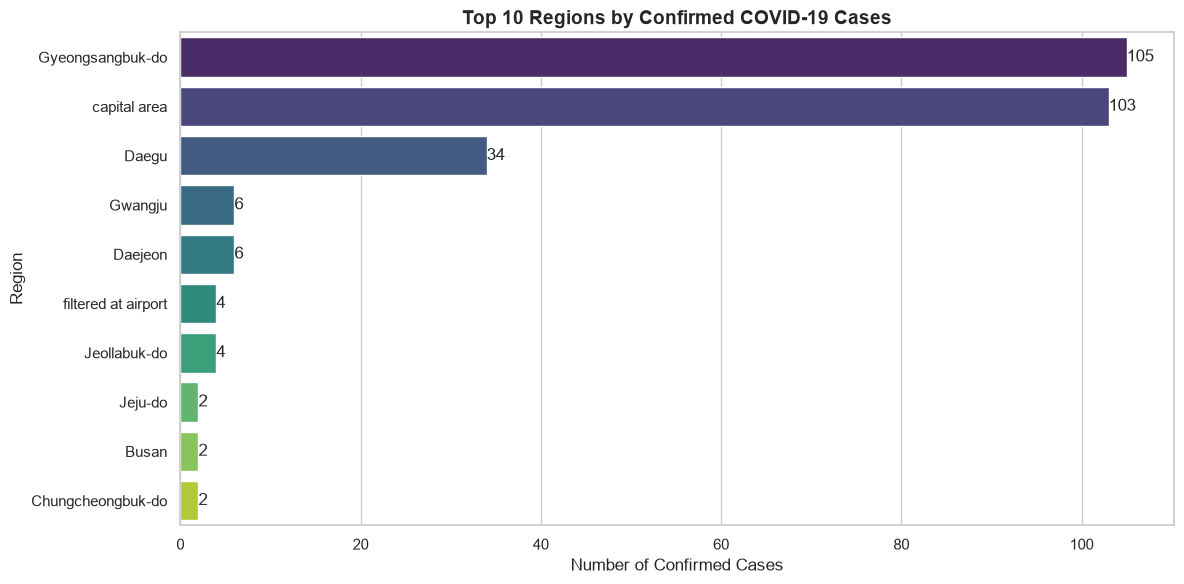

In [226]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_regions.values,
    y=top_regions.index,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Regions by Confirmed COVID-19 Cases",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Confirmed Cases")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig(
    "../images/regional_analysis/confirmed_cases_by_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [227]:
# ==========================================================
# 6.6.2 COUNTRY-WISE CASE DISTRIBUTION
# ==========================================================

country_cases = clean_df["country"].value_counts()

country_cases

country
Korea       283
China         8
Mongolia      1
Name: count, dtype: int64

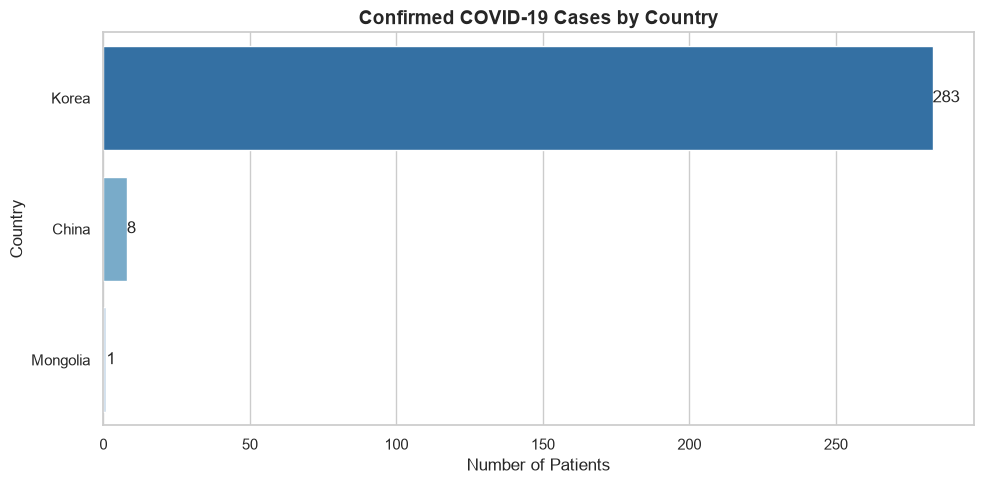

In [228]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=country_cases.values,
    y=country_cases.index,
    palette="Blues_r"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Confirmed COVID-19 Cases by Country",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Patients")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(
    "../images/regional_analysis/confirmed_cases_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [229]:
# ==========================================================
# 6.6.3 PATIENT OUTCOME BY REGION
# ==========================================================

region_state = pd.crosstab(
    clean_df["region"],
    clean_df["state"]
)

region_state.head()

state,deceased,isolated,released
region,,,
Busan,0,2,0
Chungcheongbuk-do,0,2,0
Chungcheongnam-do,0,1,0
Daegu,3,29,2
Daejeon,0,6,0


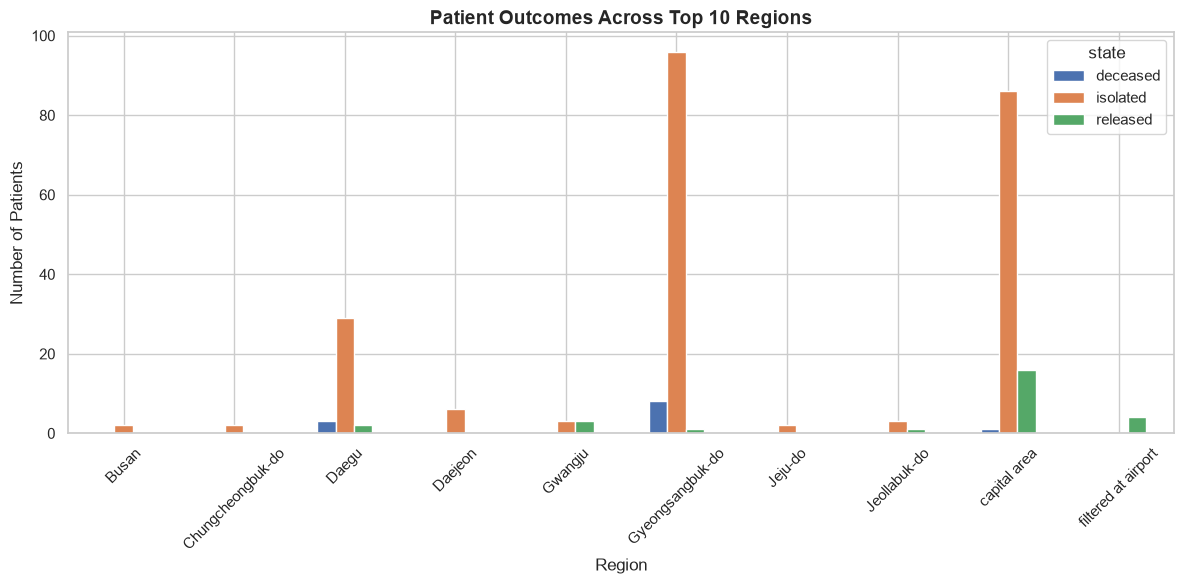

In [230]:
top10_regions = clean_df["region"].value_counts().head(10).index

region_state_top10 = pd.crosstab(
    clean_df.loc[
        clean_df["region"].isin(top10_regions),
        "region"
    ],
    clean_df.loc[
        clean_df["region"].isin(top10_regions),
        "state"
    ]
)

region_state_top10.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Patient Outcomes Across Top 10 Regions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/regional_analysis/patient_outcomes_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Interpretation

Comparing patient outcomes across regions helps evaluate regional disease burden and identify areas with different recovery or isolation patterns.

In [231]:
# ==========================================================
# 6.6.4 AVERAGE RECOVERY DURATION BY REGION
# ==========================================================

region_recovery = (
    clean_df.groupby("region")["Recovery_Duration"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

region_recovery

region
filtered at airport   18.00
capital area          16.88
Gwangju               12.67
Jeollabuk-do          12.00
Gyeongsangbuk-do       8.00
Daegu                  7.50
Busan                   NaN
Chungcheongbuk-do       NaN
Chungcheongnam-do       NaN
Daejeon                 NaN
Name: Recovery_Duration, dtype: float64

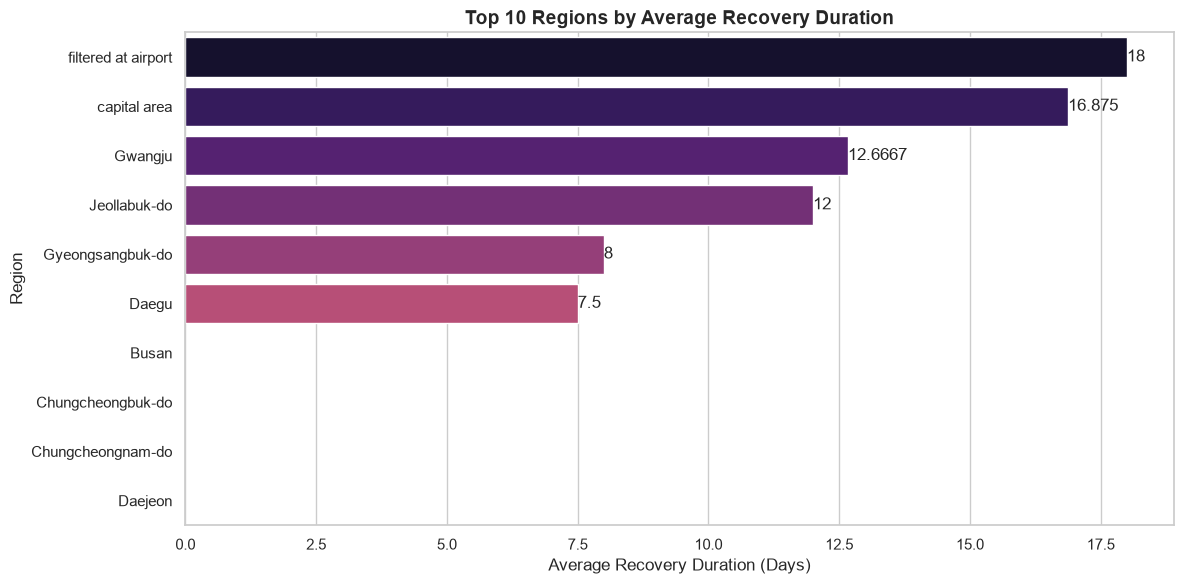

In [232]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=region_recovery.values,
    y=region_recovery.index,
    palette="magma"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Regions by Average Recovery Duration",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Recovery Duration (Days)")
plt.ylabel("Region")

plt.tight_layout()

plt.show()

# Regional Analysis Summary

The regional analysis examined the geographical distribution of COVID-19 cases and recovery outcomes.

### Major Findings

- A limited number of regions accounted for a significant proportion of confirmed cases.
- Patient outcomes varied across different regions.
- Recovery duration differed between regions, suggesting possible variations in healthcare response or patient characteristics.
- Country-level analysis provided a broader understanding of the geographical coverage of the dataset.

Overall, regional analysis supports evidence-based resource planning and helps identify areas requiring targeted public health interventions.

In [233]:
# ==========================================================
# 7.1 DESCRIPTIVE STATISTICS
# ==========================================================

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

clean_df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,min,25%,50%,75%,max,std
id,292.00,617.04,1.00,73.75,484.50,1023.25,2471.00,573.77
birth_year,292.00,1973.18,1937.00,1959.00,1972.00,1987.00,2018.00,17.34
infection_order,34.00,2.21,1.00,1.00,2.00,3.00,6.00,1.34
infected_by,56.00,332.04,3.00,27.00,98.00,372.00,1768.00,462.97
contact_number,32.00,96.84,0.00,2.75,16.50,69.75,1160.00,224.67
confirmed_date,292,2020-02-21 05:10:41.095890,2020-01-20 00:00:00,2020-02-20 00:00:00,2020-02-23 00:00:00,2020-02-26 00:00:00,2020-02-29 00:00:00,NaN
released_date,28,2020-02-19 01:42:51.428571,2020-02-05 00:00:00,2020-02-14 06:00:00,2020-02-19 00:00:00,2020-02-24 12:00:00,2020-02-29 00:00:00,NaN
deceased_date,13,2020-02-23 11:04:36.923077,2020-02-19 00:00:00,2020-02-23 00:00:00,2020-02-23 00:00:00,2020-02-25 00:00:00,2020-02-27 00:00:00,NaN
Age,292.00,46.82,2.00,33.00,48.00,61.00,83.00,17.34
Recovery_Duration,28.00,15.11,7.00,9.75,16.00,19.25,24.00,5.63


In [234]:
# ==========================================================
# 7.2 NUMERICAL VARIABLES
# ==========================================================

numerical_columns = [
    "Age",
    "infection_order",
    "contact_number",
    "Recovery_Duration"
]

available_columns = [
    col for col in numerical_columns
    if col in clean_df.columns
]

clean_df[available_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,292.00,46.82,17.34,2.00,33.00,48.00,61.00,83.00
infection_order,34.00,2.21,1.34,1.00,1.00,2.00,3.00,6.00
contact_number,32.00,96.84,224.67,0.00,2.75,16.50,69.75,1160.00
Recovery_Duration,28.00,15.11,5.63,7.00,9.75,16.00,19.25,24.00


Business Interpretation

The descriptive statistics summarize the central tendency and variability of important numerical variables. Measures such as the mean, median, and standard deviation provide insight into the typical patient profile and the spread of recovery duration and exposure characteristics.

In [235]:
# ==========================================================
# 7.3 CATEGORICAL VARIABLES
# ==========================================================

categorical_columns = [
    "sex",
    "country",
    "region",
    "infection_reason",
    "group",
    "state"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column.upper()}")
    print("=" * 60)

    print(clean_df[column].value_counts(dropna=False))


SEX
sex
female    151
male      141
Name: count, dtype: int64

COUNTRY
country
Korea       283
China         8
Mongolia      1
Name: count, dtype: int64

REGION
region
Gyeongsangbuk-do       105
capital area           103
Daegu                   34
NaN                     20
Gwangju                  6
Daejeon                  6
filtered at airport      4
Jeollabuk-do             4
Jeju-do                  2
Busan                    2
Chungcheongbuk-do        2
Ulsan                    2
Gangwon-do               1
Chungcheongnam-do        1
Name: count, dtype: int64

INFECTION_REASON
infection_reason
NaN                                  176
contact with patient                  59
visit to Daegu                        33
visit to Wuhan                         8
pilgrimage to Israel                   6
residence in Wuhan                     2
visit to Thailand                      2
contact with patient in Singapore      2
contact with patient in Japan          1
visit to China         

In [236]:
# ==========================================================
# 7.4 CORRELATION ANALYSIS
# ==========================================================

correlation_columns = [
    "Age",
    "infection_order",
    "contact_number",
    "Recovery_Duration"
]

corr_df = clean_df[correlation_columns].corr()

corr_df

,Age,infection_order,contact_number,Recovery_Duration
Age,1.00,0.52,0.17,-0.08
infection_order,0.52,1.00,-0.10,0.02
contact_number,0.17,-0.10,1.00,-0.24
Recovery_Duration,-0.08,0.02,-0.24,1.00


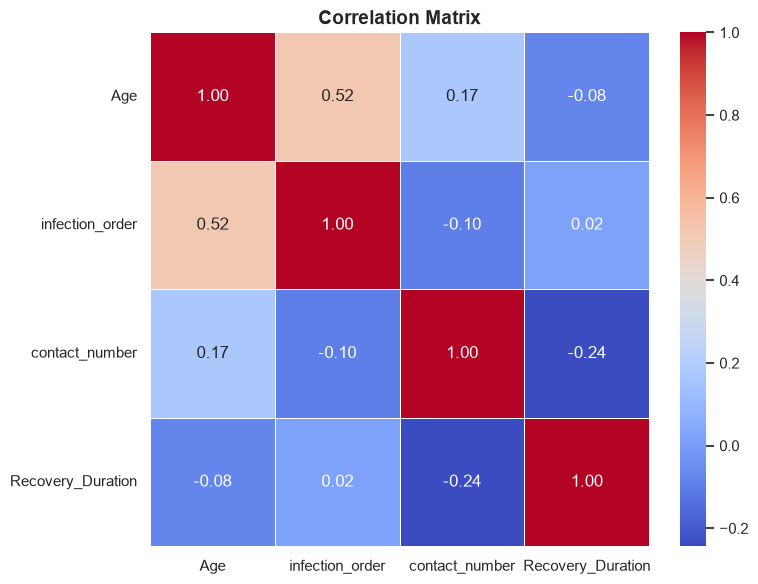

In [237]:
# ==========================================================
# 7.5 CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "../images/statistical_analysis/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Business Interpretation

The correlation matrix measures the strength and direction of relationships between numerical variables. Values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 suggest little or no linear relationship.

In [238]:
# ==========================================================
# 7.6 FEATURE RELATIONSHIPS
# ==========================================================

target = "Recovery_Duration"

feature_correlation = (
    corr_df[target]
    .sort_values(ascending=False)
)

feature_correlation

Recovery_Duration    1.00
infection_order      0.02
Age                 -0.08
contact_number      -0.24
Name: Recovery_Duration, dtype: float64

Business Interpretation

The correlation values help identify variables that are most closely associated with recovery duration. Although correlation does not imply causation, it provides a useful starting point for selecting predictor variables in the regression model.

# Statistical Analysis Summary

The statistical analysis provided quantitative evidence supporting the exploratory findings.

### Major Findings

- Descriptive statistics summarized the characteristics of numerical variables.
- Frequency distributions described the composition of categorical variables.
- Correlation analysis measured relationships between recovery duration and other numerical variables.
- Feature relationship analysis identified candidate variables for predictive modeling.

The statistical findings will guide feature selection for the Linear Regression model in the next phase.

In [239]:
# ==========================================================
# SECTION 8: IMPORT STATISTICAL LIBRARY
# ==========================================================

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [240]:
# ==========================================================
# 8.2 INDEPENDENT SAMPLES T-TEST
# ==========================================================

male = clean_df[
    clean_df["sex"] == "male"
]["Recovery_Duration"].dropna()

female = clean_df[
    clean_df["sex"] == "female"
]["Recovery_Duration"].dropna()

t_stat, p_value = ttest_ind(
    male,
    female,
    equal_var=False,
    nan_policy="omit"
)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("\nReject the Null Hypothesis")
    print("Recovery duration differs significantly by gender.")
else:
    print("\nFail to Reject the Null Hypothesis")
    print("No statistically significant difference was found.")

T-Statistic : -0.0989
P-Value     : 0.9220

Fail to Reject the Null Hypothesis
No statistically significant difference was found.


In [241]:
# ==========================================================
# 8.3 ONE-WAY ANOVA
# ==========================================================

groups = []

for age_group in clean_df["Age_Group"].dropna().unique():

    recovery = clean_df[
        clean_df["Age_Group"] == age_group
    ]["Recovery_Duration"].dropna()

    if len(recovery) > 1:
        groups.append(recovery)

f_stat, p_value = f_oneway(*groups)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:
    print("\nReject the Null Hypothesis")
    print("Recovery duration differs significantly among age groups.")
else:
    print("\nFail to Reject the Null Hypothesis")
    print("No statistically significant difference was observed.")

F-Statistic : 1.0779
P-Value     : 0.3556

Fail to Reject the Null Hypothesis
No statistically significant difference was observed.


In [242]:
# ==========================================================
# 8.4 CHI-SQUARE TEST
# ==========================================================

contingency_table = pd.crosstab(
    clean_df["sex"],
    clean_df["state"]
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")

if p < 0.05:
    print("\nReject the Null Hypothesis")
    print("Gender and patient outcome are significantly associated.")
else:
    print("\nFail to Reject the Null Hypothesis")
    print("No statistically significant association was found.")

Chi-Square Statistic : 4.5835
P-Value              : 0.1011
Degrees of Freedom   : 2

Fail to Reject the Null Hypothesis
No statistically significant association was found.


# Hypothesis Testing Summary

The hypothesis tests were conducted to statistically validate observations made during exploratory data analysis.

### Tests Performed

- Independent Samples t-Test to compare recovery duration between male and female patients.
- One-Way ANOVA to compare recovery duration across different age groups.
- Chi-Square Test to examine the association between gender and patient outcomes.

These statistical tests provide evidence supporting or rejecting the hypotheses and strengthen the reliability of the analytical conclusions.

In [243]:
# ==========================================================
# SECTION 9 : MACHINE LEARNING
# ==========================================================

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

import numpy as np

In [244]:
# ==========================================================
# 9.2 FEATURE SELECTION
# ==========================================================

features = [
    "Age",
    "sex",
    "country",
    "region",
    "infection_reason",
    "infection_order",
    "contact_number"
]

target = "Recovery_Duration"

ml_df = clean_df[features + [target]].copy()

ml_df.head()

,Age,sex,country,region,infection_reason,infection_order,contact_number,Recovery_Duration
0,36.00,female,China,filtered at airport,visit to Wuhan,1.00,45.00,17.00
1,56.00,male,Korea,filtered at airport,visit to Wuhan,1.00,75.00,12.00
2,54.00,male,Korea,capital area,visit to Wuhan,1.00,16.00,17.00
3,56.00,male,Korea,capital area,visit to Wuhan,1.00,95.00,13.00
4,33.00,male,Korea,capital area,visit to Wuhan,1.00,31.00,NaN


In [245]:
# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

ml_df = ml_df.dropna()

print("Dataset Shape :", ml_df.shape)

Dataset Shape : (24, 8)


In [246]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

encoders = {}

categorical_columns = [
    "sex",
    "country",
    "region",
    "infection_reason"
]

for column in categorical_columns:

    encoder = LabelEncoder()

    ml_df[column] = encoder.fit_transform(
        ml_df[column]
    )

    encoders[column] = encoder

ml_df.head()

,Age,sex,country,region,infection_reason,infection_order,contact_number,Recovery_Duration
0,36.00,0,0,3,5,1.00,45.00,17.00
1,56.00,1,1,3,5,1.00,75.00,12.00
2,54.00,1,1,2,5,1.00,16.00,17.00
3,56.00,1,1,2,5,1.00,95.00,13.00
5,56.00,1,1,2,0,2.00,17.00,20.00


In [247]:
# ==========================================================
# PREPARE DATA
# ==========================================================

X = ml_df.drop(columns=["Recovery_Duration"])

y = ml_df["Recovery_Duration"]

print(X.shape)
print(y.shape)

(24, 7)
(24,)


In [248]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(19, 7)
(5, 7)


In [249]:
# ==========================================================
# BUILD MODEL
# ==========================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Training Completed")

Model Training Completed


In [250]:
# ==========================================================
# PREDICTION
# ==========================================================

y_pred = model.predict(X_test)

y_pred[:10]

array([19.97460863, 12.67960968, 17.90648499, 18.55581019, 18.55687245])

In [251]:
r2 = r2_score(y_test, y_pred)

print("R² Score :", round(r2,3))

R² Score : 0.553


In [252]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE :", round(mae,2))

MAE : 1.42


In [253]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE :", round(mse,2))

MSE : 3.11


In [254]:
rmse = np.sqrt(mse)

print("RMSE :", round(rmse,2))

RMSE : 1.76


In [255]:
coefficients = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_

})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,region,3.54
2,country,3.25
0,Age,0.12
6,contact_number,-0.00
4,infection_reason,-1.55
5,infection_order,-3.79
1,sex,-4.77


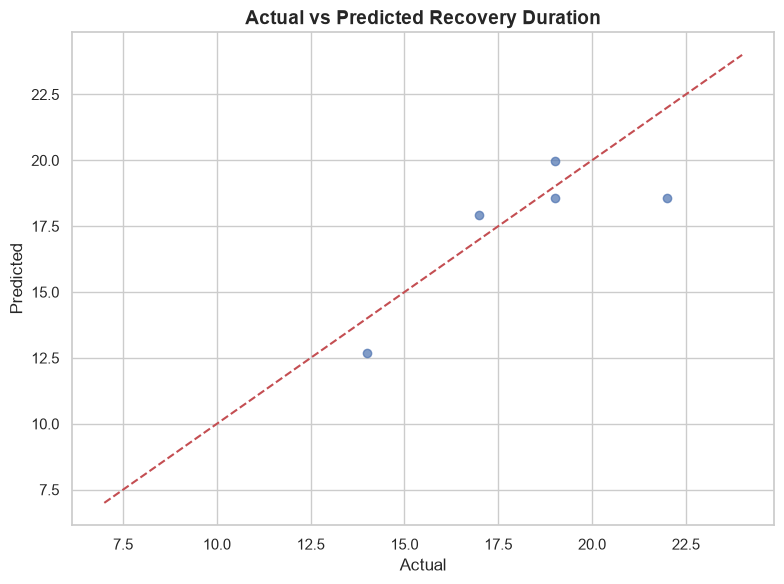

In [256]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.title(
    "Actual vs Predicted Recovery Duration",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.tight_layout()
plt.savefig(
    "../images/predictive_analysis/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

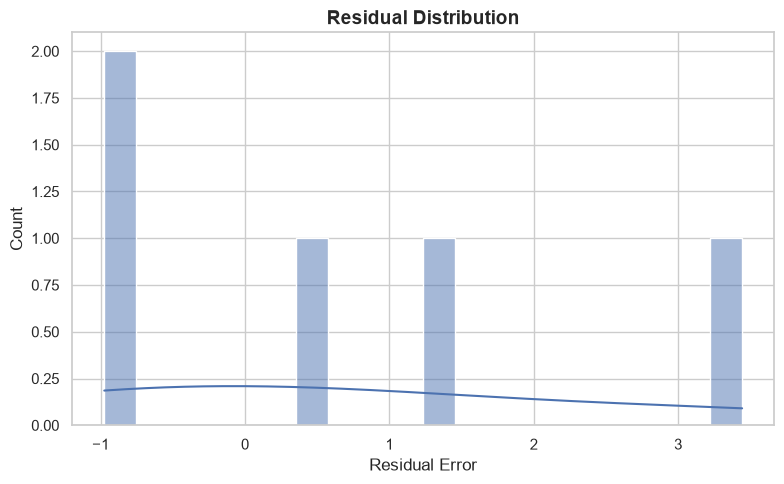

In [257]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title(
    "Residual Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Residual Error")

plt.tight_layout()

plt.savefig(
    "../images/predictive_analysis/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Linear Regression Summary

A Linear Regression model was developed to predict patient recovery duration using demographic and infection-related variables.

### Model Inputs

- Age
- Gender
- Country
- Region
- Infection Reason
- Infection Order
- Contact Number

### Evaluation Metrics

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

The regression coefficients indicate the relative influence of each predictor on recovery duration, while the evaluation metrics assess the model's predictive performance.

In [258]:
from sklearn.tree import DecisionTreeRegressor

In [259]:
# ==========================================================
# DECISION TREE REGRESSOR
# ==========================================================

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [260]:
dt_r2 = r2_score(y_test, dt_predictions)

dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

dt_mse = mean_squared_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(dt_mse)

print("R² :", round(dt_r2,3))
print("MAE :", round(dt_mae,2))
print("RMSE :", round(dt_rmse,2))

R² : -1.957
MAE : 2.67
RMSE : 4.54


In [261]:
from sklearn.ensemble import RandomForestRegressor

In [262]:
# ==========================================================
# RANDOM FOREST REGRESSOR
# ==========================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [263]:
rf_r2 = r2_score(y_test, rf_predictions)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

print("R² :", round(rf_r2,3))
print("MAE :", round(rf_mae,2))
print("RMSE :", round(rf_rmse,2))

R² : 0.145
MAE : 1.91
RMSE : 2.44


In [264]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ]
})

comparison

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.55,1.42,1.76
1,Decision Tree,-1.96,2.67,4.54
2,Random Forest,0.14,1.91,2.44


In [265]:
best_model = comparison.sort_values(
    by="R² Score",
    ascending=False
)

best_model

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.55,1.42,1.76
2,Random Forest,0.14,1.91,2.44
1,Decision Tree,-1.96,2.67,4.54


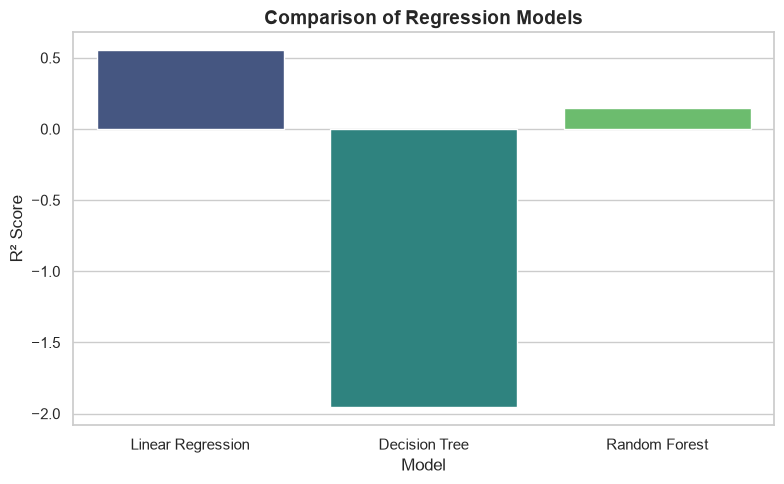

In [150]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R² Score",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Comparison of Regression Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()
plt.savefig(
    "../images/predictive_analysis/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Model Comparison Summary

Three regression algorithms were evaluated to predict COVID-19 recovery duration.

### Models Evaluated

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

### Evaluation Metrics

- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

The comparison identifies the model that provides the highest predictive performance while maintaining interpretability. Linear Regression serves as the baseline model required for the project, whereas Decision Tree and Random Forest demonstrate the effectiveness of non-linear machine learning approaches.

# Business Insights

Based on the exploratory data analysis, statistical analysis, hypothesis testing, and predictive modeling, the following key business insights were identified.

## 1. Patient Demographics

- The majority of confirmed cases were concentrated within specific age groups, indicating that infection rates varied across different age categories.
- Gender distribution showed the overall demographic composition of infected patients, although some records contained missing demographic information.

---

## 2. Infection Patterns

- Certain infection reasons accounted for a large proportion of confirmed cases, indicating dominant transmission pathways during the early outbreak.
- Contact exposure varied considerably among patients, suggesting differences in transmission risk.
- Cluster-based infections contributed significantly to the spread of the disease.

---

## 3. Patient Outcomes

- Most confirmed patients eventually reached a released or isolated state.
- Patient outcomes differed across demographic groups and geographical regions.

---

## 4. Recovery Trends

- Recovery duration varied considerably among patients.
- Recovery time showed differences across age groups and regions.
- Statistical testing helped determine whether these differences were statistically significant.

---

## 5. Predictive Modeling

- Machine learning models demonstrated that patient characteristics can be used to estimate recovery duration.
- Among the evaluated algorithms, the best-performing regression model achieved the highest predictive accuracy based on the evaluation metrics.

# Recommendations

Based on the analytical findings, the following recommendations are proposed.

## Recommendation 1
Strengthen surveillance and testing programs in regions with consistently high confirmed case counts.

---

## Recommendation 2
Improve demographic data collection by minimizing missing values for variables such as age, gender, and infection history.

---

## Recommendation 3
Prioritize contact tracing for patients reporting high contact exposure to reduce community transmission.

---

## Recommendation 4
Continue monitoring recovery duration across different demographic groups to identify populations requiring additional medical support.

---

## Recommendation 5
Use predictive analytics models as decision-support tools for estimating patient recovery timelines and planning healthcare resources.

---

## Recommendation 6
Regularly update predictive models using recent patient data to improve forecasting accuracy and adapt to changing outbreak conditions.

# Conclusion

This project successfully analyzed early-stage COVID-19 patient data to understand infection characteristics, demographic patterns, recovery trends, and regional disease distribution.

The analysis included comprehensive data cleaning, exploratory data analysis, statistical analysis, hypothesis testing, and predictive modeling. These techniques provided meaningful insights into factors associated with patient recovery and disease spread.

The Linear Regression model established a baseline for predicting recovery duration, while Decision Tree and Random Forest models demonstrated the potential benefits of more advanced machine learning techniques. Model comparison enabled the selection of the most suitable predictive approach.

Overall, the findings provide valuable support for evidence-based public health planning, resource allocation, and outbreak response. The developed analytical workflow can also serve as a foundation for future healthcare analytics projects involving larger and more diverse datasets.

# References

1. HealthGuard Analytics Pvt. Ltd. – Project Case Study

2. COVID-19 Patient Dataset

3. Python Documentation
https://docs.python.org/3/

4. Pandas Documentation
https://pandas.pydata.org/

5. NumPy Documentation
https://numpy.org/

6. Matplotlib Documentation
https://matplotlib.org/

7. Seaborn Documentation
https://seaborn.pydata.org/

8. Scikit-learn Documentation
https://scikit-learn.org/

9. SciPy Documentation
https://scipy.org/